# Enhanced Handwritten Digit Recognizer (MNIST)

**Improvements over baseline:**
- Deeper CNN with 3 convolutional blocks
- Batch Normalization for faster, more stable training
- Dropout layers to reduce overfitting
- EarlyStopping + ReduceLROnPlateau callbacks
- ModelCheckpoint to save best weights
- Training history visualization
- Confidence scores in prediction output

In [6]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import models, layers, callbacks, Input
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 1. Load & Preprocess Data

In [7]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# Reshape to (N, 28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

print(f"Training samples : {x_train.shape[0]}")
print(f"Test samples     : {x_test.shape[0]}")
print(f"Input shape      : {x_train.shape[1:]}")

Training samples : 60000
Test samples     : 10000
Input shape      : (28, 28, 1)


## 2. Data Augmentation

Augmentation techniques applied:
1. **Rotation** — slight tilts (±10°) mimic real handwriting
2. **Width / Height Shift** — small translations
3. **Zoom** — slight scale variation

> Horizontal/vertical flipping is intentionally **excluded** — flipping digits changes their meaning (e.g., 6 ↔ 9).

In [8]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
datagen.fit(x_train)

## 3. Model Architecture

**Enhanced CNN** with 3 convolutional blocks:

| Block | Layers |
|-------|--------|
| Conv Block 1 | Conv2D(32) → BatchNorm → ReLU → MaxPool |
| Conv Block 2 | Conv2D(64) → BatchNorm → ReLU → MaxPool |
| Conv Block 3 | Conv2D(128) → BatchNorm → ReLU → MaxPool |
| Head | Flatten → Dense(256) → Dropout(0.5) → Dense(10, softmax) |

In [9]:
def build_enhanced_model():
    model = models.Sequential([
        Input(shape=(28, 28, 1)),

        # --- Block 1 ---
        layers.Conv2D(32, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(32, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # --- Block 2 ---
        layers.Conv2D(64, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(64, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # --- Block 3 ---
        layers.Conv2D(128, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # --- Classifier Head ---
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax")
    ])
    return model

model = build_enhanced_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 438,890 (1.67 MB)

 Trainable params: 437,738 (1.67 MB)

 Non-trainable params: 1,152 (4.50 KB)

## 4. Compile & Setup Callbacks

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callback_list = [
    # Stop training when val_loss stops improving for 5 epochs
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    # Halve LR when val_loss plateaus for 3 epochs
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    # Save best model weights
    callbacks.ModelCheckpoint(
        filepath="best_mnist_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

print("Model compiled. Callbacks configured.")

Model compiled. Callbacks configured.


## 5. Train the Model

In [ ]:
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=5,                           # EarlyStopping will cut this short if needed
    validation_data=(x_test, y_test),    # Monitor generalisation each epoch
    callbacks=callback_list
)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9819 - loss: 0.0601
Epoch 1: val_accuracy improved from 0.99130 to 0.99310, saving model to best_mnist_model.keras

Epoch 1: finished saving model to best_mnist_model.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 74ms/step - accuracy: 0.9819 - loss: 0.0590 - val_accuracy: 0.9931 - val_loss: 0.0202 - learning_rate: 0.0010
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9824 - loss: 0.0570
Epoch 2: val_accuracy did not improve from 0.99310
938/938 ━━━━━━━━━━━━━━━━━━━━ 71s 76ms/step - accuracy: 0.9832 - loss: 0.0543 - val_accuracy: 0.9889 - val_loss: 0.0315 - learning_rate: 0.0010
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9850 - loss: 0.0501
Epoch 3: val_accuracy improved from 0.99310 to 0.99400, saving model to best_mnist_model.keras

Epoch 3: finished saving model to best_mnist_model.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 71s 75ms/step - accuracy: 0.9844 - loss: 0.0504 - val_accuracy: 0.9940

## 6. Evaluate & Visualize Training

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy : {test_acc * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")


Test Accuracy : 99.72%
Test Loss     : 0.0093


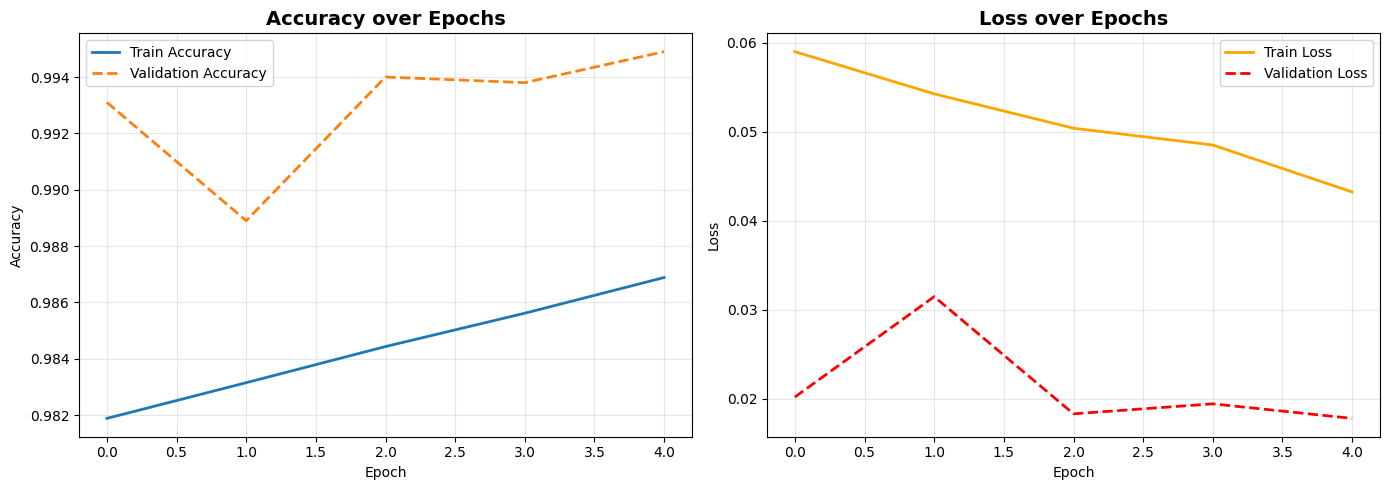

Plot saved to training_history.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy ---
axes[0].plot(history.history["accuracy"],     label="Train Accuracy",      linewidth=2)
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy",  linewidth=2, linestyle="--")
axes[0].set_title("Accuracy over Epochs", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Loss ---
axes[1].plot(history.history["loss"],     label="Train Loss",      linewidth=2, color="orange")
axes[1].plot(history.history["val_loss"], label="Validation Loss",  linewidth=2, linestyle="--", color="red")
axes[1].set_title("Loss over Epochs", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to training_history.png")

## 7. Predict a Custom Image

The function below returns:
- The **predicted digit**
- The **confidence** (probability) for the top prediction
- The **top-3 candidates** in case the model is uncertain

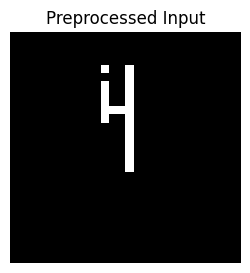


  Predicted Digit : 1
  Confidence      : 99.0%
  Top-3 candidates:
    1. Digit 1 |  99.0% ███████████████████
    2. Digit 7 |   0.4% 
    3. Digit 2 |   0.3% 



(1, 0.9896119236946106)

In [15]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_digit(img_path, show_image=True):
    # Load & resize & convert to grayscale
    img = keras_image.load_img(img_path, color_mode="grayscale", target_size=(28, 28))
    img_array = keras_image.img_to_array(img) / 255.0

    # Invert if background is white (MNIST uses white digit on black)
    if img_array.mean() > 0.5:
        img_array = 1.0 - img_array

    if show_image:
        plt.figure(figsize=(3, 3))
        plt.imshow(img_array.squeeze(), cmap="gray")
        plt.title("Preprocessed Input")
        plt.axis("off")
        plt.show()

    img_array = img_array.reshape(1, 28, 28, 1)
    probs = model.predict(img_array, verbose=0)[0]

    predicted_digit = int(np.argmax(probs))
    confidence      = float(probs[predicted_digit])

    top3_idx = np.argsort(probs)[::-1][:3]
    top3     = [(int(i), float(probs[i])) for i in top3_idx]

    print(f"\n{'='*35}")
    print(f"  Predicted Digit : {predicted_digit}")
    print(f"  Confidence      : {confidence*100:.1f}%")
    print(f"  Top-3 candidates:")
    for rank, (digit, prob) in enumerate(top3, 1):
        bar = '█' * int(prob * 20)
        print(f"    {rank}. Digit {digit} | {prob*100:5.1f}% {bar}")
    print(f"{'='*35}\n")

    return predicted_digit, confidence


# ── Takes filename as input ──────────────────────────────────────
img_path = input("Enter image filename (e.g. digit.png): ").strip()
predict_digit(img_path)

## 8. (Optional) Load Best Saved Model

The `ModelCheckpoint` callback saved the best weights during training. Reload them any time:

In [17]:
# Uncomment to reload the best checkpoint:
# model = tf.keras.models.load_model("best_mnist_model.keras")
# print("Best model loaded.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


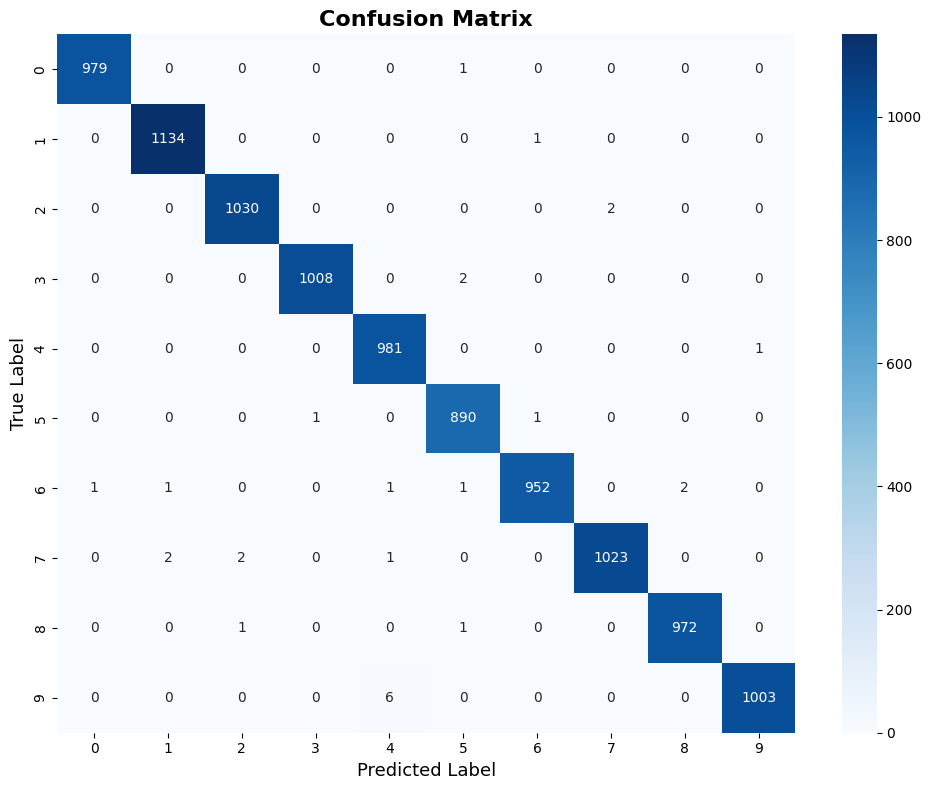

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = np.argmax(model.predict(x_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10))
plt.title("Confusion Matrix", fontsize=16, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=13)
plt.ylabel("True Label", fontsize=13)
plt.tight_layout()
plt.show()